# 테일러 급수와 미적분학에 대한 디스커션-11강 3기 10강

In [1]:
import math

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, a, c, t = sp.symbols("x a c t", real=True)

## 2. 테일러 급수와 라그랑주 나머지항
$f(x)=\sum_{k=0}^{n}\frac{f^{(k)}(a)}{k!}(x-a)^k+R_n(x)$, 라그랑주 형태
$R_n(x)=\dfrac{f^{(n+1)}(c)}{(n+1)!}(x-a)^{n+1}$. SymPy 의 테일러 전개와 직접 비교합니다.

In [2]:
f = sp.exp(x)
# Taylor polynomial of degree n at a=0, and the symbolic remainder term O(...) stripped
for n in [1, 2, 3, 4]:
    poly = sp.series(f, x, 0, n + 1).removeO()
    print(f"n={n}:  P_n(x) = {sp.expand(poly)}")

# Lagrange remainder bound for e^x on [0, 1]: |R_n(1)| <= e^c/(n+1)! <= e/(n+1)!
print("\nLagrange remainder bound for e^x at x=1 (c in [0,1], so f^(n+1)(c)=e^c <= e):")
for n in [1, 2, 3, 4, 5]:
    bound = sp.E / sp.factorial(n + 1)
    actual = abs(sp.exp(1) - sp.series(f, x, 0, n + 1).removeO().subs(x, 1))
    print(f"  n={n}:  |R_n(1)| = {float(actual):.3e}   <=   e/(n+1)! = {float(bound):.3e}")

n=1:  P_n(x) = x + 1
n=2:  P_n(x) = x**2/2 + x + 1
n=3:  P_n(x) = x**3/6 + x**2/2 + x + 1
n=4:  P_n(x) = x**4/24 + x**3/6 + x**2/2 + x + 1

Lagrange remainder bound for e^x at x=1 (c in [0,1], so f^(n+1)(c)=e^c <= e):
  n=1:  |R_n(1)| = 7.183e-01   <=   e/(n+1)! = 1.359e+00
  n=2:  |R_n(1)| = 2.183e-01   <=   e/(n+1)! = 4.530e-01
  n=3:  |R_n(1)| = 5.162e-02   <=   e/(n+1)! = 1.133e-01
  n=4:  |R_n(1)| = 9.948e-03   <=   e/(n+1)! = 2.265e-02
  n=5:  |R_n(1)| = 1.615e-03   <=   e/(n+1)! = 3.775e-03


## 5. 첫 비영 항의 차수와 부호가 국소 모양을 정한다
$x^4$ 는 첫 비영 항이 짝수차(양수)라 원점에서 양쪽이 올라가 **극소**,
$x^3$ 은 홀수차라 좌우 부호가 바뀌어 **변곡점**. 둘 다 원점에서 $f''=0$.

In [3]:
for expr in [x**3, x**4, -x**4]:
    d2 = sp.diff(expr, x, 2)
    # first nonzero derivative order at 0
    k = 1
    while sp.diff(expr, x, k).subs(x, 0) == 0:
        k += 1
    coeff = sp.diff(expr, x, k).subs(x, 0)
    parity = "even" if k % 2 == 0 else "odd"
    shape = "inflection (sign flips)" if k % 2 else ("local min" if coeff > 0 else "local max")
    print(f"{str(expr):>6}:  f''(0)={d2.subs(x,0)},  first nonzero deriv order={k} ({parity}),  -> {shape}")

  x**3:  f''(0)=0,  first nonzero deriv order=3 (odd),  -> inflection (sign flips)
  x**4:  f''(0)=0,  first nonzero deriv order=4 (even),  -> local min
 -x**4:  f''(0)=0,  first nonzero deriv order=4 (even),  -> local max


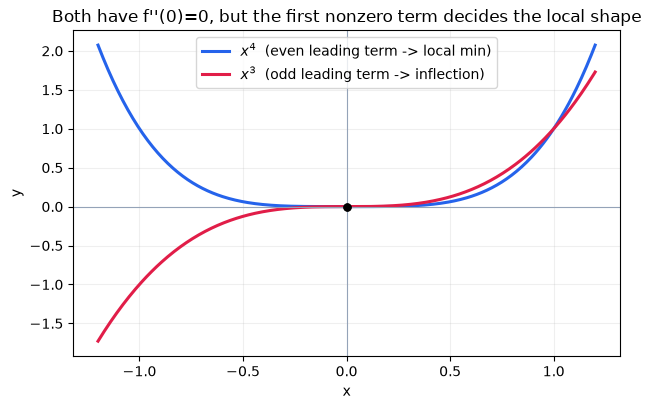

In [4]:
xs = np.linspace(-1.2, 1.2, 400)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(xs, xs**4, color="#2563eb", lw=2.2, label=r"$x^4$  (even leading term -> local min)")
ax.plot(xs, xs**3, color="#e11d48", lw=2.2, label=r"$x^3$  (odd leading term -> inflection)")
ax.axhline(0, color="#94a3b8", lw=0.8)
ax.axvline(0, color="#94a3b8", lw=0.8)
ax.scatter([0, 0], [0, 0], color="black", zorder=5, s=25)
ax.set_title("Both have f''(0)=0, but the first nonzero term decides the local shape")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(loc="upper center"); ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 7. 수렴반경: 등비급수가 어디서 의미 있는가
$\dfrac{1}{1-x}=1+x+x^2+\cdots$ 는 $|x|<1$ 에서만 맞습니다.
$x=1/2$ 는 $2$ 로 수렴, $x=2$ 는 발산.

In [5]:
def geom_partial(xv, N):
    return sum(xv**k for k in range(N + 1))

for xv in [0.5, 0.9, 1.0, 2.0]:
    closed = "1/(1-x) = {:.4f}".format(1 / (1 - xv)) if abs(xv) < 1 else "diverges (|x|>=1)"
    print(f"x={xv:>4}:  partial sum N=20 -> {geom_partial(xv, 20):12.4f}    closed form: {closed}")

x= 0.5:  partial sum N=20 ->       2.0000    closed form: 1/(1-x) = 2.0000
x= 0.9:  partial sum N=20 ->       8.9058    closed form: 1/(1-x) = 10.0000
x= 1.0:  partial sum N=20 ->      21.0000    closed form: diverges (|x|>=1)
x= 2.0:  partial sum N=20 -> 2097151.0000    closed form: diverges (|x|>=1)


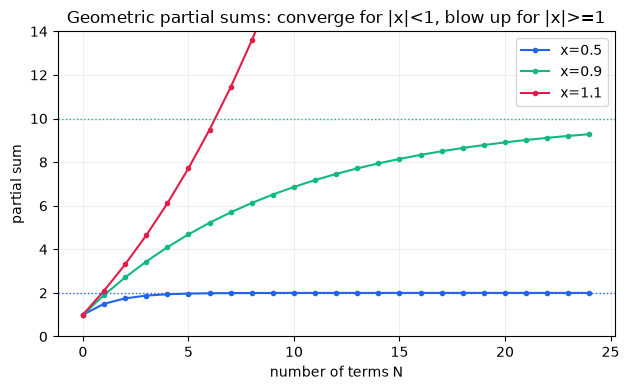

In [6]:
N = np.arange(0, 25)
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for xv, color in [(0.5, "#2563eb"), (0.9, "#10b981"), (1.1, "#e11d48")]:
    partials = np.array([geom_partial(xv, n) for n in N])
    ax.plot(N, partials, marker="o", ms=3, color=color, label=f"x={xv}")
ax.axhline(1 / (1 - 0.5), color="#2563eb", ls=":", lw=1)
ax.axhline(1 / (1 - 0.9), color="#10b981", ls=":", lw=1)
ax.set_ylim(0, 14)
ax.set_title("Geometric partial sums: converge for |x|<1, blow up for |x|>=1")
ax.set_xlabel("number of terms N"); ax.set_ylabel("partial sum")
ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 9. FTC와 테일러 급수: 원시함수를 몰라도 적분하기
$e^{-x^2}$ 의 원시함수는 초등함수가 아니지만, 테일러 전개
$e^{-x^2}=\sum_k \frac{(-1)^k}{k!}x^{2k}$ 를 **항별 적분**하면
$\int_0^1 e^{-x^2}dx=\sum_k \frac{(-1)^k}{k!(2k+1)}$ 로 근사할 수 있습니다.

In [7]:
# Term-by-term integral of e^{-x^2} on [0,1]:  sum_k (-1)^k / (k! (2k+1))
true_val = sp.integrate(sp.exp(-x**2), (x, 0, 1))
true_num = float(true_val)
print("exact (erf form):", true_val, "=", f"{true_num:.10f}")

partial = sp.Integer(0)
print("\nTerm-by-term partial sums  sum_k (-1)^k / (k!(2k+1)):")
for k in range(8):
    term = sp.Rational((-1)**k, sp.factorial(k) * (2 * k + 1))
    partial += term
    print(f"  up to k={k}:  {float(partial):.10f}   (error {abs(float(partial)-true_num):.2e})")

exact (erf form): sqrt(pi)*erf(1)/2 = 0.7468241328

Term-by-term partial sums  sum_k (-1)^k / (k!(2k+1)):
  up to k=0:  1.0000000000   (error 2.53e-01)
  up to k=1:  0.6666666667   (error 8.02e-02)
  up to k=2:  0.7666666667   (error 1.98e-02)
  up to k=3:  0.7428571429   (error 3.97e-03)
  up to k=4:  0.7474867725   (error 6.63e-04)
  up to k=5:  0.7467291967   (error 9.49e-05)
  up to k=6:  0.7468360343   (error 1.19e-05)
  up to k=7:  0.7468228068   (error 1.33e-06)


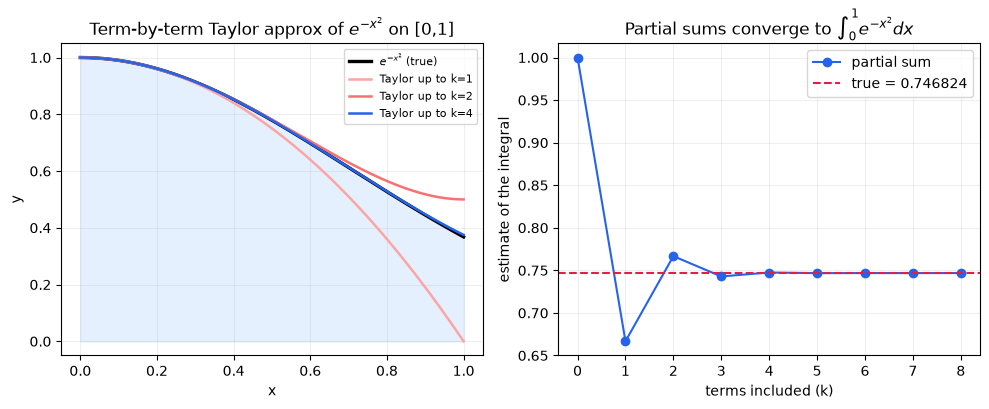

In [8]:
# Visualize: partial-sum Taylor approximations of e^{-x^2} and the area they integrate
xs = np.linspace(0, 1, 300)


def taylor_exp_neg_sq(xv, K):
    return sum(((-1.0) ** k) / math.factorial(k) * xv ** (2 * k) for k in range(K + 1))


fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

ax = axes[0]
ax.plot(xs, np.exp(-xs**2), color="black", lw=2.4, label=r"$e^{-x^2}$ (true)")
for K, color in [(1, "#fca5a5"), (2, "#f87171"), (4, "#2563eb")]:
    ax.plot(xs, taylor_exp_neg_sq(xs, K), color=color, lw=1.8, label=f"Taylor up to k={K}")
ax.fill_between(xs, np.exp(-xs**2), color="#bfdbfe", alpha=0.4)
ax.set_title("Term-by-term Taylor approx of $e^{-x^2}$ on [0,1]")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes[1]
Ks = np.arange(0, 9)
sums = []
acc = 0.0
for k in Ks:
    acc += ((-1.0) ** k) / (math.factorial(k) * (2 * k + 1))
    sums.append(acc)
ax.plot(Ks, sums, marker="o", color="#2563eb", label="partial sum")
ax.axhline(true_num, color="#e11d48", ls="--", lw=1.5, label=f"true = {true_num:.6f}")
ax.set_title("Partial sums converge to $\\int_0^1 e^{-x^2}dx$")
ax.set_xlabel("terms included (k)"); ax.set_ylabel("estimate of the integral")
ax.legend(); ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()